In [32]:
import os
import re
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature, filters
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [2]:
home = 'images'
directories = 'train', 'test', 'val'
class_names = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

In [3]:
def read_file_to_list(file_path):
    numbers_list = []
    with open(file_path, 'r') as file:
        for line in file:
            number = int(line.strip())
            numbers_list.append(number)
        return numbers_list

In [4]:
y_train = read_file_to_list(f'{home}/{directories[0]}.txt')
y_test = read_file_to_list(f'{home}/{directories[1]}.txt')
y_val = read_file_to_list(f'{home}/{directories[2]}.txt')

In [5]:
train_folder = os.path.join(home, directories[0])
test_folder = os.path.join(home, directories[1])
val_folder = os.path.join(home, directories[2])

def get_image_content(folder_path):
    image_contents = []

    def extract_number(filename):
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else -1

    filenames = sorted(os.listdir(folder_path), key=extract_number)

    for filename in filenames:
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename.endswith('.png'):
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            image_contents.append(image)

    return image_contents

x_train = get_image_content(train_folder)
x_test = get_image_content(test_folder)
x_val = get_image_content(val_folder)

In [6]:
def to_histogram(photos: list, original=False):
    result = []
    for photo in photos:
        hist = np.histogram(photo, bins=256)[0]
        if original is True:
            hist[:5] = 0
        result.append(hist)
    return result

def to_lbp(photos: list, num_points: int = 8, radius: int = 1):
    result = []
    for photo in photos:
        result.append(feature.local_binary_pattern(photo, num_points, radius, method='uniform'))
    return result

def to_pca(photos: list, n_components: int):
    pca = PCA(n_components=n_components)
    conv_photos = np.array(photos).reshape(len(photos), -1)
    return pca.fit_transform(conv_photos), np.sum(pca.explained_variance_ratio_)

def to_sobel(photos: list):
    sobel = lambda image: filters.sobel(image)
    conv_photos = np.array(photos).reshape(len(photos), -1)
    result = [sobel(image) for image in conv_photos]
    return result

def to_clahe(photos: list, clip=5):
    result = []
    clahe = cv2.createCLAHE(clipLimit=clip)
    for photo in photos:
        final_img = clahe.apply(photo) + 30
        result.append(final_img)
    return result


Image histogram

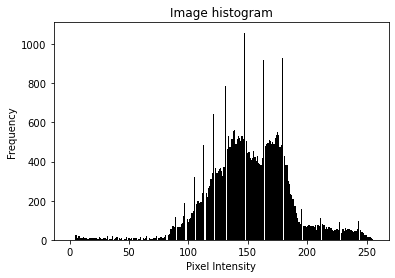

In [10]:
hist = np.histogram(x_train[0], bins=256)[0]
hist[:5] = 0
plt.bar(range(256), hist, width=1.0, color='black')
plt.title('Image histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

In [7]:
def train_classifier(classifier, param_grid, x_train, cv = 5):
    grid_search = GridSearchCV(classifier, param_grid, cv=cv, verbose=0)
    grid_search.fit(x_train, y_train)
    best_model = grid_search.best_estimator_
    return best_model, grid_search.best_params_

def evaluate(classifiers, x_train, x_val):
  for classifier, param_grid in classifiers:
    best_model, best_params = train_classifier(classifier, param_grid, x_train)
    y_pred = best_model.predict(x_val)

    print(f'{classifier.__class__.__name__}')
    print('Best Parameters:', best_params)
    report = classification_report(y_val, y_pred, output_dict=True, digits=4)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']
    accuracy = report['accuracy']
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1_score}')
    print(f'Accuracy: {accuracy}')
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')
    plt.show()

In [8]:
rf_param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'n_jobs': [-1]}
knn_param_grid = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance'], 'n_jobs': [-1]}
adaboost_param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}
xgboost_param_grid = {'n_estimators': [50, 100, 150],
                      'max_depth': [3, 4, 5],
                      'n_jobs': [-1]}
classifiers = [
    (RandomForestClassifier(), rf_param_grid),
    (KNeighborsClassifier(), knn_param_grid),
    (AdaBoostClassifier(), adaboost_param_grid),
    (xgb.XGBClassifier(), xgboost_param_grid)
]

# Original

In [9]:
x_train_hist = to_histogram(x_train, original=True)
x_test_hist = to_histogram(x_test, original=True)
x_val_hist = to_histogram(x_val, original=True)

RandomForestClassifier
Best Parameters: {'max_depth': 20, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.7813106480459157
Recall: 0.7701421800947867
F1 Score: 0.7716200359001002
Accuracy: 0.7701421800947867


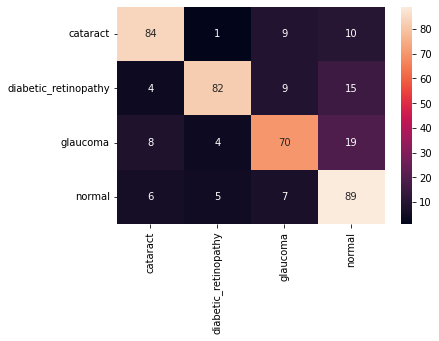

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 3, 'weights': 'distance'}
Precision: 0.6541651987939507
Recall: 0.6635071090047393
F1 Score: 0.6488809182846844
Accuracy: 0.6635071090047393


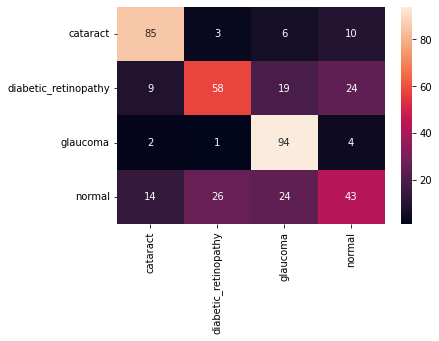

AdaBoostClassifier
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Precision: 0.6960040583043327
Recall: 0.6706161137440758
F1 Score: 0.6662380008673152
Accuracy: 0.6706161137440758


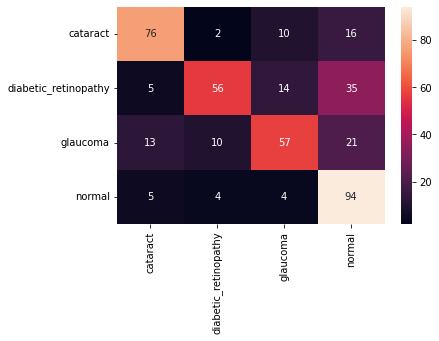

XGBClassifier
Best Parameters: {'max_depth': 5, 'n_estimators': 150, 'n_jobs': -1}
Precision: 0.7877979411775753
Recall: 0.7819905213270142
F1 Score: 0.782909782630375
Accuracy: 0.7819905213270142


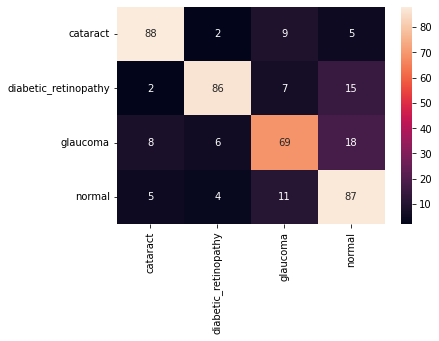

In [10]:
evaluate(classifiers, x_train_hist, x_val_hist)

# LBP

In [11]:
del x_train_hist, x_test_hist, x_val_hist
x_train_lbp = to_lbp(x_train)
x_test_lbp = to_lbp(x_test)
x_val_lbp = to_lbp(x_val)

x_train_hist = to_histogram(x_train_lbp)
x_test_hist = to_histogram(x_test_lbp)
x_val_hist = to_histogram(x_val_lbp)

RandomForestClassifier
Best Parameters: {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.7356127173745858
Recall: 0.7274881516587678
F1 Score: 0.7298668664639348
Accuracy: 0.7274881516587678


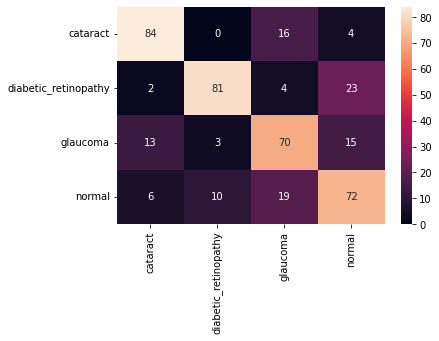

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 7, 'weights': 'distance'}
Precision: 0.6895824009676533
Recall: 0.6848341232227488
F1 Score: 0.6854135152840531
Accuracy: 0.6848341232227488


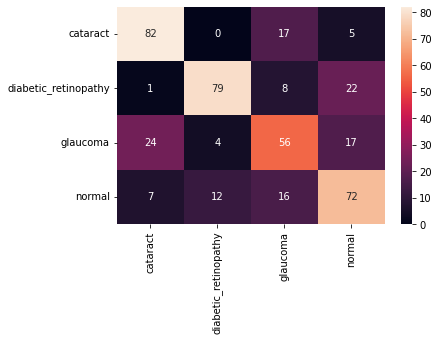

AdaBoostClassifier
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Precision: 0.7035432544022591
Recall: 0.6469194312796208
F1 Score: 0.6543756896561671
Accuracy: 0.6469194312796208


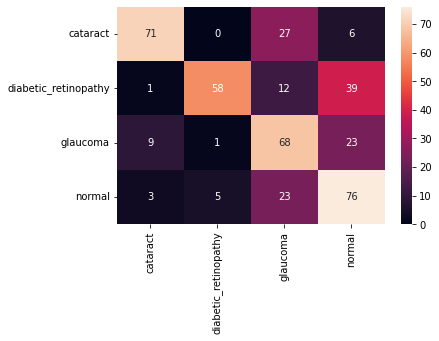

XGBClassifier
Best Parameters: {'max_depth': 5, 'n_estimators': 150, 'n_jobs': -1}
Precision: 0.7358872393784758
Recall: 0.7274881516587678
F1 Score: 0.7303108210721005
Accuracy: 0.7274881516587678


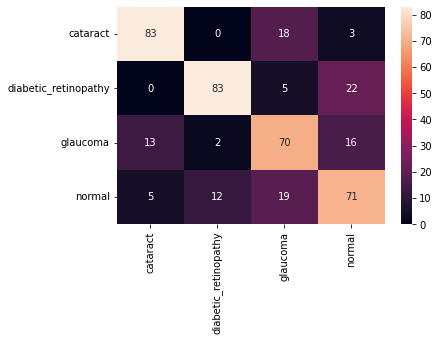

In [12]:
evaluate(classifiers, x_train_hist, x_val_hist)

# PCA

In [18]:
del x_train_lbp, x_test_lbp, x_val_lbp
del x_train_hist, x_test_hist, x_val_hist
x_train_pca, _ = to_pca(x_train, 30)
x_test_pca, _ = to_pca(x_test, 30)
x_val_pca, _ = to_pca(x_val, 30)

RandomForestClassifier
Best Parameters: {'max_depth': 20, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.5619207414052326
Recall: 0.5355450236966824
F1 Score: 0.5405767142491466
Accuracy: 0.5355450236966824


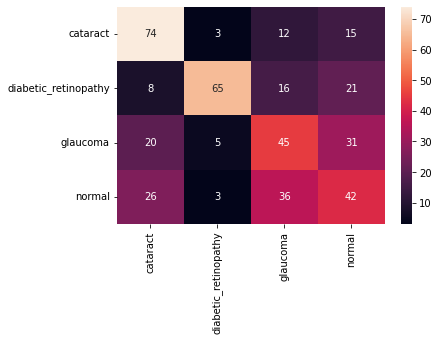

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 5, 'weights': 'distance'}
Precision: 0.5159216420129316
Recall: 0.504739336492891
F1 Score: 0.5081010696058456
Accuracy: 0.504739336492891


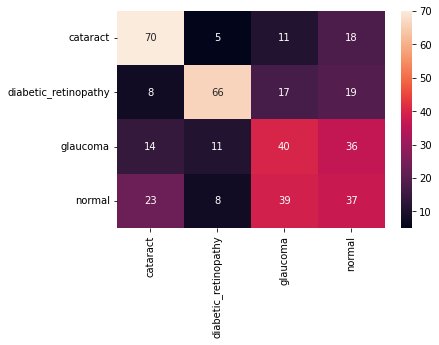

AdaBoostClassifier
Best Parameters: {'learning_rate': 1.0, 'n_estimators': 200}
Precision: 0.5218018381409976
Recall: 0.5071090047393365
F1 Score: 0.5104753220847558
Accuracy: 0.5071090047393365


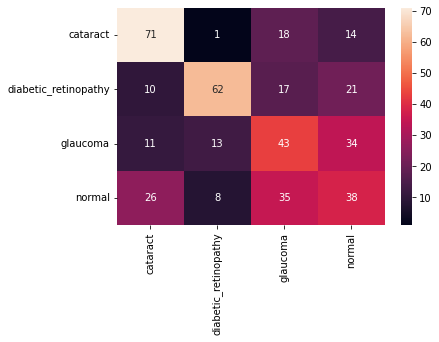

XGBClassifier
Best Parameters: {'max_depth': 5, 'n_estimators': 150, 'n_jobs': -1}
Precision: 0.5481770974028674
Recall: 0.533175355450237
F1 Score: 0.5361647560619579
Accuracy: 0.533175355450237


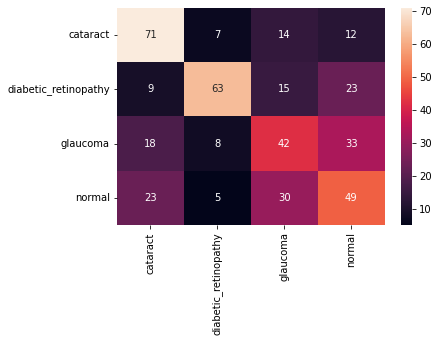

In [30]:
evaluate(classifiers, x_train_pca, x_val_pca)

# Sobel

In [34]:
del x_train_pca, x_test_pca, x_val_pca
x_train_sobel = to_sobel(x_train)
x_test_sobel = to_sobel(x_test)
x_val_sobel = to_sobel(x_val)

x_train_hist = to_histogram(x_train_sobel)
x_test_hist = to_histogram(x_test_sobel)
x_val_hist = to_histogram(x_val_sobel)

RandomForestClassifier
Best Parameters: {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.6590724441435342
Recall: 0.6658767772511849
F1 Score: 0.6507289193629748
Accuracy: 0.6658767772511849


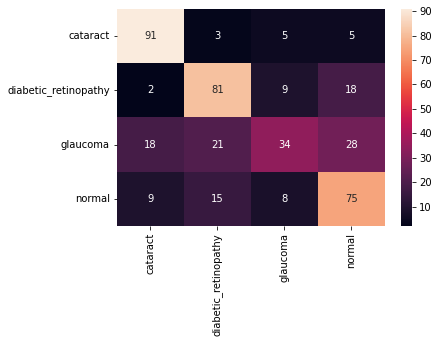

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 5, 'weights': 'distance'}
Precision: 0.4700847534194894
Recall: 0.4597156398104265
F1 Score: 0.4622965800610996
Accuracy: 0.4597156398104265


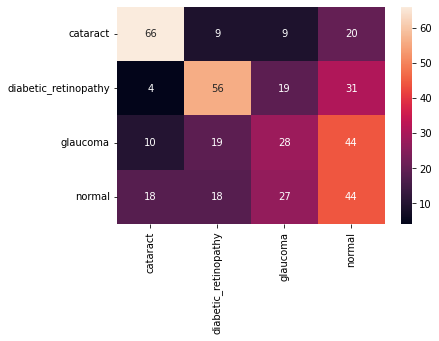

AdaBoostClassifier
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Precision: 0.6114638087611495
Recall: 0.6161137440758294
F1 Score: 0.6127560202151087
Accuracy: 0.6161137440758294


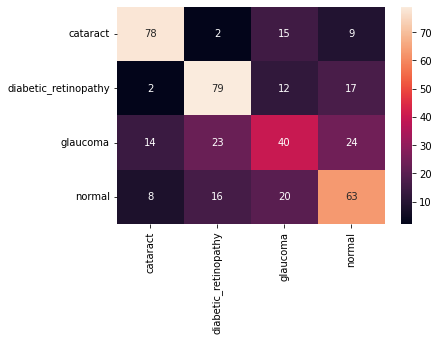

XGBClassifier
Best Parameters: {'max_depth': 3, 'n_estimators': 100, 'n_jobs': -1}
Precision: 0.6461201508919677
Recall: 0.6516587677725119
F1 Score: 0.6464568611835885
Accuracy: 0.6516587677725119


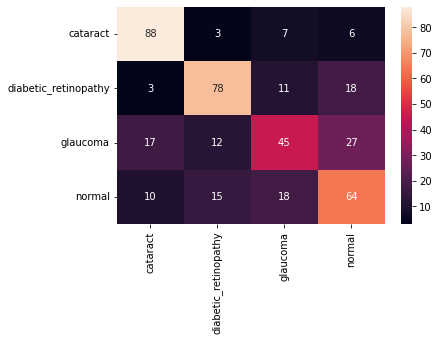

In [35]:
evaluate(classifiers, x_train_hist, x_val_hist)

# Clahe

In [36]:
del x_train_sobel, x_test_sobel, x_val_sobel
del x_train_hist, x_test_hist, x_val_hist
x_train_clahe = to_clahe(x_train)
x_test_clahe = to_clahe(x_test)
x_val_clahe = to_clahe(x_val)

x_train_hist = to_histogram(x_train_clahe)
x_test_hist = to_histogram(x_test_clahe)
x_val_hist = to_histogram(x_val_clahe)

RandomForestClassifier
Best Parameters: {'max_depth': 20, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.7820420617337493
Recall: 0.7772511848341233
F1 Score: 0.7779613780270495
Accuracy: 0.7772511848341233


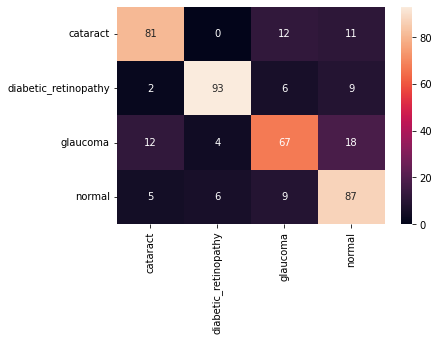

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 5, 'weights': 'distance'}
Precision: 0.710214170893268
Recall: 0.7037914691943128
F1 Score: 0.7057390021570901
Accuracy: 0.7037914691943128


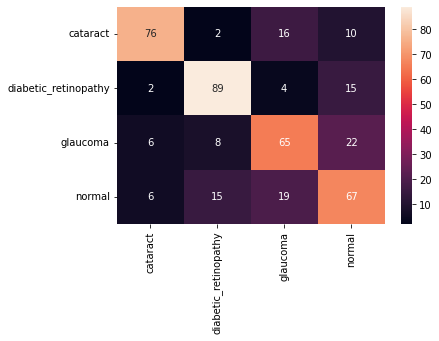

AdaBoostClassifier
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Precision: 0.7652592338516618
Recall: 0.7606635071090048
F1 Score: 0.7594301307900138
Accuracy: 0.7606635071090048


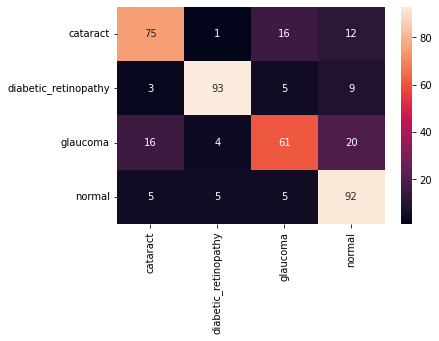

XGBClassifier
Best Parameters: {'max_depth': 4, 'n_estimators': 150, 'n_jobs': -1}
Precision: 0.8005256954707345
Recall: 0.7962085308056872
F1 Score: 0.7964517804855585
Accuracy: 0.7962085308056872


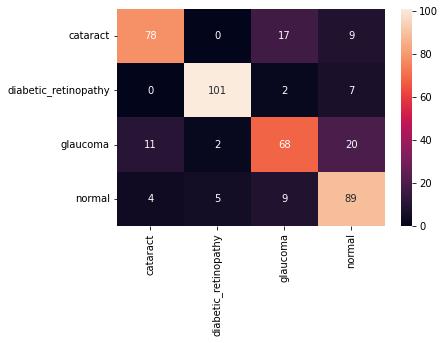

In [37]:
evaluate(classifiers, x_train_hist, x_val_hist)